# E2 · Minimum revenue with shared upside

**Optional decision:** How can a supplier and its commercial counterparty share downside protection and upside? Read M5 first; allow 10–15 minutes. This hypothetical bilateral agreement settles at month 12 for 7,200 delivered GPU-hours. The counterparty receives reference revenue from those hours and owes the supplier the agreed allocation.

Let reference revenue R equal delivered hours times reference price S. The counterparty guarantees G = 7,200 × USD 4 and pays the supplier half of revenue above G. Supplier receipts are G + alpha × max(R−G, 0), with alpha=0.5. The counterparty retains R minus supplier receipts, which can be negative.

No separate premium is charged in this example. The supplier gives up some upside, but we have not established that this concession fairly prices the guarantee. Payment is an assumed contractual promise; enforceability and counterparty credit are not modeled.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.options import european_option_payoff_usd
from liquid_compute.revenue_sharing import (
    delivered_hour_revenue_share,
    minimum_revenue_share_usd,
)

hours = 7_200
guarantee_rate = 4.0
supplier_share = 0.5
prices = (3.0, 5.0, 7.0)
settlement_month = 12
print("One bilateral allocation at month 12; no separate upfront premium.")

One bilateral allocation at month 12; no separate upfront premium.


## Work both sides before calling the calculator

At S=3, reference revenue is USD 21,600 but the guarantee is USD 28,800. The supplier receives the guarantee and the counterparty contributes USD 7,200 beyond reference revenue.

At S=7, reference revenue is USD 50,400. Half of the USD 21,600 excess goes to the supplier, whose total receipts become USD 39,600. The counterparty retains USD 10,800. In both cases, supplier allocation plus counterparty net equals reference revenue; a negative net must remain visible.

In [3]:
guarantee = hours * guarantee_rate
direct_rows = []
for price in (3, 7):
    revenue = hours * price
    supplier = guarantee + supplier_share * max(revenue - guarantee, 0)
    counterparty = revenue - supplier
    direct_rows.append(
        [price, revenue, supplier, counterparty, supplier + counterparty]
    )
show_finance_table(
    [
        "Reference USD/GPU-hour",
        "Revenue USD",
        "Supplier USD",
        "Counterparty net USD",
        "Allocation sum USD",
    ],
    direct_rows,
)

| Reference USD/GPU-hour | Revenue USD | Supplier USD | Counterparty net USD | Allocation sum USD |
| --- | --- | --- | --- | --- |
| 3.00 | 21,600.00 | 28,800.00 | -7,200.00 | 21,600.00 |
| 7.00 | 50,400.00 | 39,600.00 | 10,800.00 | 50,400.00 |

## Compare four explicitly different agreements

Compare spot receipts R, fixed receipts at USD 5/hour, a full floor max(R,G), and the shared-upside agreement. Fixed USD 5/hour is a separate benchmark contract; setting alpha to zero in the sharing agreement instead gives fixed USD 4/hour.

The shared form can be written G plus alpha times a call payoff on total revenue with strike G. Reuse M5's payoff arithmetic for that decomposition, with one normalized claim on revenue dollars. This algebra does not price the commercial guarantee or imply that a traded option is available.

In [4]:
baseline = [
    delivered_hour_revenue_share(
        delivered_gpu_hours=hours,
        reference_usd_per_gpu_hour=p,
        guarantee_usd_per_gpu_hour=guarantee_rate,
        supplier_upside_fraction=supplier_share,
    )
    for p in prices
]
show_finance_table(
    [
        "Price",
        "Spot USD",
        "Fixed at 5 USD",
        "Full floor USD",
        "Shared supplier USD",
        "Counterparty net USD",
    ],
    [
        [
            p,
            r.reference_revenue_usd,
            hours * 5,
            max(r.reference_revenue_usd, guarantee),
            r.supplier_receipts_usd,
            r.counterparty_net_usd,
        ]
        for p, r in zip(prices, baseline)
    ],
)
revenue_call = european_option_payoff_usd(
    kind="call",
    settlement_price_usd_per_gpu_hour=hours * 7,
    strike_usd_per_gpu_hour=guarantee,
    covered_gpu_hours=1,
)
print(
    f"Normalized revenue-claim decomposition at S=7: USD {guarantee + supplier_share * revenue_call:,.2f}"
)

| Price | Spot USD | Fixed at 5 USD | Full floor USD | Shared supplier USD | Counterparty net USD |
| --- | --- | --- | --- | --- | --- |
| 3.00 | 21,600.00 | 36,000.00 | 28,800.00 | 28,800.00 | -7,200.00 |
| 5.00 | 36,000.00 | 36,000.00 | 36,000.00 | 32,400.00 | 3,600.00 |
| 7.00 | 50,400.00 | 36,000.00 | 50,400.00 | 39,600.00 | 10,800.00 |

Normalized revenue-claim decomposition at S=7: USD 39,600.00


At prices 3/5/7, shared supplier receipts are USD 28,800/32,400/39,600. A full floor instead gives USD 28,800/36,000/50,400. The shared contract preserves the same downside guarantee while transferring half the excess to the counterparty.

## Explore the allocation

Plot supplier receipts and counterparty net against reference price. The negative counterparty value below the guarantee is a funding obligation, not a plotting error. Independent controls change guarantee rate and supplier upside fraction without altering fixed experiments. Editable inputs provide the same calculation when widgets are unavailable. The chart reports contractual allocations, not expected returns or present values.

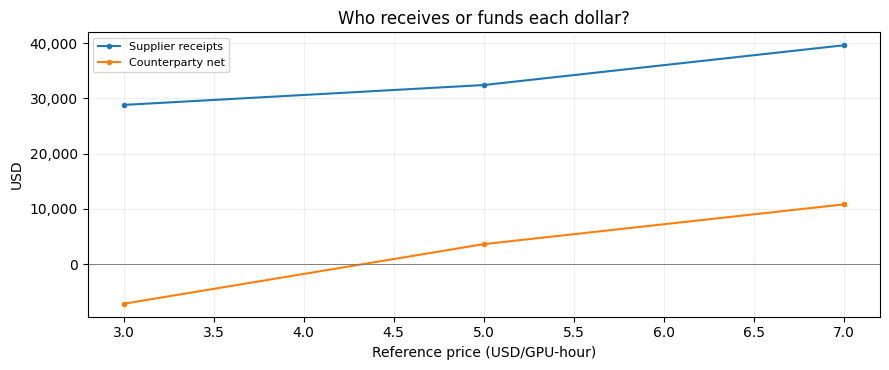

In [5]:
display(
    plot_finance_series(
        {
            "Supplier receipts": [r.supplier_receipts_usd for r in baseline],
            "Counterparty net": [r.counterparty_net_usd for r in baseline],
        },
        title="Who receives or funds each dollar?",
        xlabel="Reference price (USD/GPU-hour)",
        x_values=prices,
    )
)


def sharing_explorer(values, q=hours, grid=prices):
    from liquid_compute.revenue_sharing import delivered_hour_revenue_share

    rows = [
        delivered_hour_revenue_share(
            delivered_gpu_hours=q,
            reference_usd_per_gpu_hour=p,
            guarantee_usd_per_gpu_hour=values["Guarantee USD/GPU-hour"],
            supplier_upside_fraction=values["Supplier upside fraction"],
        )
        for p in grid
    ]
    return {
        "Supplier receipts": [r.supplier_receipts_usd for r in rows],
        "Counterparty net": [r.counterparty_net_usd for r in rows],
    }


explore_finance_series(
    {"Guarantee USD/GPU-hour": 4.0, "Supplier upside fraction": 0.5},
    sharing_explorer,
    title="Contract allocation",
    xlabel="Reference price (USD/GPU-hour)",
    x_values=prices,
);

## Experiment 1 · Change the upside fraction

Hold the guarantee at USD 4 per delivered hour and compare fractions 0, 0.5 and 1. Zero gives the supplier only the guarantee, regardless of reference revenue. One gives the entire excess to the supplier, reproducing a full floor.

The fraction changes allocation above the guarantee. Below it there is no excess to divide, so all three versions still require the counterparty to fund the same shortfall. No distribution priority among lenders or investors is involved.

In [6]:
share_cases = []
for alpha in (0, 0.5, 1):
    low = delivered_hour_revenue_share(
        delivered_gpu_hours=hours,
        reference_usd_per_gpu_hour=3,
        guarantee_usd_per_gpu_hour=4,
        supplier_upside_fraction=alpha,
    )
    high = delivered_hour_revenue_share(
        delivered_gpu_hours=hours,
        reference_usd_per_gpu_hour=7,
        guarantee_usd_per_gpu_hour=4,
        supplier_upside_fraction=alpha,
    )
    share_cases.append(
        [
            alpha,
            low.supplier_receipts_usd,
            high.supplier_receipts_usd,
            high.counterparty_net_usd,
        ]
    )
show_finance_table(
    [
        "Supplier fraction",
        "Supplier at 3 USD",
        "Supplier at 7 USD",
        "Counterparty at 7 USD",
    ],
    share_cases,
)

| Supplier fraction | Supplier at 3 USD | Supplier at 7 USD | Counterparty at 7 USD |
| --- | --- | --- | --- |
| 0.00 | 28,800.00 | 28,800.00 | 21,600.00 |
| 0.50 | 28,800.00 | 39,600.00 | 10,800.00 |
| 1.00 | 28,800.00 | 50,400.00 | 0.00 |

At price 7, supplier receipts rise from USD 28,800 to USD 39,600 to USD 50,400 as participation increases. Counterparty retained upside falls correspondingly. At price 3, the supplier still receives USD 28,800 in each case.

## Experiment 2 · Increase the guarantee

Restore half participation and compare guarantee rates 3/4/5 while reference price is 3. A higher guarantee increases the payer's downside contribution. The calculation does not establish whether a counterparty would accept those terms, what fee it would demand, or whether its resources can support the promise.

In [7]:
guarantee_cases = [
    delivered_hour_revenue_share(
        delivered_gpu_hours=hours,
        reference_usd_per_gpu_hour=3,
        guarantee_usd_per_gpu_hour=g,
        supplier_upside_fraction=0.5,
    )
    for g in (3, 4, 5)
]
show_finance_table(
    ["Guarantee rate", "Supplier USD", "Counterparty net USD"],
    [
        [g, r.supplier_receipts_usd, r.counterparty_net_usd]
        for g, r in zip((3, 4, 5), guarantee_cases)
    ],
)

| Guarantee rate | Supplier USD | Counterparty net USD |
| --- | --- | --- |
| 3.00 | 21,600.00 | 0.00 |
| 4.00 | 28,800.00 | -7,200.00 |
| 5.00 | 36,000.00 | -14,400.00 |

The counterparty contributes USD 0, USD 7,200 or USD 14,400 at the three guarantee rates. Greater supplier protection creates a greater obligation on the other side.

## Experiment 3 · Deliver fewer hours

Set delivered quantity to 3,600 while reference price is 5. Under the baseline **per-delivered-hour** guarantee, G falls to USD 14,400. Compare that with a separately specified **fixed-total** guarantee of USD 28,800, which remains payable despite fewer hours.

These are different obligations. Never preserve a fixed total silently while describing terms as per-hour. At zero delivery, the per-hour guarantee is zero, while the assumed unconditional fixed-total guarantee still requires payment.

In [8]:
quantity_cases = []
for delivered in (3_600, 0):
    per_hour = delivered_hour_revenue_share(
        delivered_gpu_hours=delivered,
        reference_usd_per_gpu_hour=5,
        guarantee_usd_per_gpu_hour=4,
        supplier_upside_fraction=0.5,
    )
    fixed_total = minimum_revenue_share_usd(
        reference_revenue_usd=delivered * 5,
        guaranteed_revenue_usd=28_800,
        supplier_upside_fraction=0.5,
    )
    quantity_cases.append(
        [
            delivered,
            per_hour.supplier_receipts_usd,
            fixed_total.supplier_receipts_usd,
            fixed_total.counterparty_net_usd,
        ]
    )
show_finance_table(
    [
        "Delivered GPU-hours",
        "Per-hour supplier USD",
        "Fixed-total supplier USD",
        "Fixed-total counterparty USD",
    ],
    quantity_cases,
)

| Delivered GPU-hours | Per-hour supplier USD | Fixed-total supplier USD | Fixed-total counterparty USD |
| --- | --- | --- | --- |
| 3,600.00 | 16,200.00 | 28,800.00 | -10,800.00 |
| 0.00 | 0.00 | 28,800.00 | -28,800.00 |

At 3,600 hours, per-hour supplier receipts are USD 16,200. Fixed-total receipts remain USD 28,800, leaving the counterparty USD 10,800 out of pocket against USD 18,000 reference revenue. At zero delivery the assumed fixed-total payment remains USD 28,800.

## State the guarantee before valuing it

The summary returns to the baseline allocation. Confirm who owes the guarantee, which quantity determines it, when payment occurs and how excess revenue is shared. Those contractual choices precede any valuation or credit analysis. A favorable supplier receipt is not automatically profit after procurement and operating costs.

In [9]:
show_finance_table(
    ["Baseline price", "Supplier receipts USD", "Counterparty net USD"],
    [
        [p, r.supplier_receipts_usd, r.counterparty_net_usd]
        for p, r in zip(prices, baseline)
    ],
)

| Baseline price | Supplier receipts USD | Counterparty net USD |
| --- | --- | --- |
| 3.00 | 28,800.00 | -7,200.00 |
| 5.00 | 32,400.00 | 3,600.00 |
| 7.00 | 39,600.00 | 10,800.00 |

**Next:** E3 optionally adds power costs for the party that pays them, or return to the core market-risk track. The planned capstone may use this agreement only when explicitly selected.

E2 allocates operating revenue between counterparties; F9 distributes cash among operating uses, debt, reserves and equity. These are different questions. M5 supplies the payoff concept, with [OIC call terminology](https://www.optionseducation.org/strategies/all-strategies/long-call) as background. No real commercial agreement, fair premium, collateral arrangement or default protection is claimed.